In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

# Flushing-round recalculation for the v3 analysis note.
# MPT.csv stores the midpoint time of each collection interval (days). Reconstruct
# the interval end time recursively, then integrate Q over each interval.
Vw_mL = 38.33
mpt_days = np.loadtxt('./data/MPT.csv', delimiter=',')

interval_end_days = np.empty_like(mpt_days, dtype=float)
previous_end = 0.0
for i, midpoint in enumerate(mpt_days):
    interval_end_days[i] = 2 * midpoint - previous_end
    previous_end = interval_end_days[i]

interval_days = np.diff(interval_end_days, prepend=0.0)
interval_minutes = interval_days * 24 * 60

case_order = [
    ('4C', 'S'), ('4C', 'M'), ('4C', 'L'),
    ('20C', 'S'), ('20C', 'M'), ('20C', 'L'),
    ('40C', 'S'), ('40C', 'M'), ('40C', 'L'),
]

temp_labels = {'4C': '4 degC', '20C': '20 degC', '40C': '40 degC'}
size_labels = {'S': '90-212 um', 'M': '212-500 um', 'L': '500-1000 um'}

round_rows = []
volume_rows = []
for temp, size in case_order:
    q_path = f'./data/Q_{temp}_{size}.csv'
    q_mL_min = np.genfromtxt(q_path, delimiter=',')
    if q_mL_min.ndim == 1:
        q_mL_min = q_mL_min[:, np.newaxis]

    volume_mL_by_rep = np.cumsum(q_mL_min * interval_minutes[:, np.newaxis], axis=0)
    flushing_rounds_by_rep = volume_mL_by_rep / Vw_mL

    mean_rounds = np.nanmean(flushing_rounds_by_rep, axis=1)
    mean_volume = np.nanmean(volume_mL_by_rep, axis=1)

    round_rows.append({
        'Temp': temp_labels[temp],
        'Size': size_labels[size],
        **{f'Pt{i + 1}': value for i, value in enumerate(mean_rounds)},
    })
    volume_rows.append({
        'Temp': temp_labels[temp],
        'Size': size_labels[size],
        **{f'Pt{i + 1}': value for i, value in enumerate(mean_volume)},
    })

flushing_round_table_v3 = pd.DataFrame(round_rows)
cumulative_volume_table_v3 = pd.DataFrame(volume_rows)
interval_table_v3 = pd.DataFrame({
    'Pt': [f'Pt{i + 1}' for i in range(len(mpt_days))],
    'MPT_days': mpt_days,
    'interval_end_days': interval_end_days,
    'interval_days': interval_days,
    'interval_minutes': interval_minutes,
})

print(f'Effective pore-water volume Vw = {Vw_mL:.2f} mL')
print('Integration uses Q_i * interval_minutes_i, where interval endpoints are reconstructed from MPT midpoints.')
print('Sampling interval check:')
display(interval_table_v3.round({'MPT_days': 3, 'interval_end_days': 3, 'interval_days': 3, 'interval_minutes': 1}))

print('Mean cumulative pumped volume (mL):')
display(cumulative_volume_table_v3.round(1))

print('Mean flushing rounds = cumulative pumped volume / Vw:')
display(flushing_round_table_v3.round(2))


Effective pore-water volume Vw = 38.33 mL
Integration uses Q_i * interval_minutes_i, where interval endpoints are reconstructed from MPT midpoints.
Sampling interval check:


,Pt,MPT_days,interval_end_days,interval_days,interval_minutes
0,Pt1,0.065,0.13,0.13,187.2
1,Pt2,0.190,0.25,0.12,172.8
2,Pt3,0.375,0.50,0.25,360.0
3,Pt4,0.750,1.00,0.50,720.0
4,Pt5,1.500,2.00,1.00,1440.0
5,Pt6,3.000,4.00,2.00,2880.0
6,Pt7,6.000,8.00,4.00,5760.0
7,Pt8,11.500,15.00,7.00,10080.0
8,Pt9,23.500,32.00,17.00,24480.0


Mean cumulative pumped volume (mL):


,Temp,Size,Pt1,Pt2,Pt3,Pt4,Pt5,Pt6,Pt7,Pt8,Pt9
0,4 degC,90-212 um,78.6,99.4,149.8,250.6,466.6,898.6,1762.6,2468.2,5895.4
1,4 degC,212-500 um,39.3,61.8,115.8,223.8,425.4,828.6,1635.0,3046.2,6228.6
2,4 degC,500-1000 um,88.0,112.2,169.8,285.0,501.0,933.0,1797.0,2603.4,5296.2
3,20 degC,90-212 um,26.2,33.1,61.9,177.1,450.7,1141.9,1545.1,3157.9,6340.3
4,20 degC,212-500 um,18.7,25.6,54.4,169.6,486.4,1177.6,1580.8,3193.6,6620.8
5,20 degC,500-1000 um,30.0,36.9,65.7,180.9,497.7,1131.3,1534.5,3147.3,6574.5
6,40 degC,90-212 um,30.0,57.6,111.6,219.6,435.6,781.2,1242.0,2350.8,5043.6
7,40 degC,212-500 um,28.1,52.3,102.7,153.1,181.9,527.5,1161.1,2169.1,4617.1
8,40 degC,500-1000 um,30.0,57.6,111.6,219.6,435.6,781.2,1242.0,2350.8,5043.6


Mean flushing rounds = cumulative pumped volume / Vw:


,Temp,Size,Pt1,Pt2,Pt3,Pt4,Pt5,Pt6,Pt7,Pt8,Pt9
0,4 degC,90-212 um,2.05,2.59,3.91,6.54,12.17,23.44,45.98,64.39,153.81
1,4 degC,212-500 um,1.03,1.61,3.02,5.84,11.10,21.62,42.66,79.47,162.50
2,4 degC,500-1000 um,2.30,2.93,4.43,7.43,13.07,24.34,46.88,67.92,138.17
3,20 degC,90-212 um,0.68,0.86,1.62,4.62,11.76,29.79,40.31,82.39,165.41
4,20 degC,212-500 um,0.49,0.67,1.42,4.43,12.69,30.72,41.24,83.32,172.73
5,20 degC,500-1000 um,0.78,0.96,1.71,4.72,12.98,29.51,40.03,82.11,171.52
6,40 degC,90-212 um,0.78,1.50,2.91,5.73,11.36,20.38,32.40,61.33,131.58
7,40 degC,212-500 um,0.73,1.36,2.68,3.99,4.74,13.76,30.29,56.59,120.46
8,40 degC,500-1000 um,0.78,1.50,2.91,5.73,11.36,20.38,32.40,61.33,131.58


n_figure_2_v3: alpha-boxplot four-panel figure with Vw=38.33 mL flushing masks
Example case 20C_S: N > 1.0, first retained point Pt3, retained points=7
4C_S: alpha mask starts at Pt1, retained points=9
4C_M: alpha mask starts at Pt1, retained points=9
4C_L: alpha mask starts at Pt1, retained points=9
20C_S: alpha mask starts at Pt3, retained points=7
20C_M: alpha mask starts at Pt3, retained points=7
20C_L: alpha mask starts at Pt3, retained points=7
40C_S: alpha mask starts at Pt2, retained points=8
40C_M: alpha mask starts at Pt2, retained points=8
40C_L: alpha mask starts at Pt2, retained points=8


C:\Users\huan111\AppData\Local\Temp\ipykernel_37496\4194178904.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


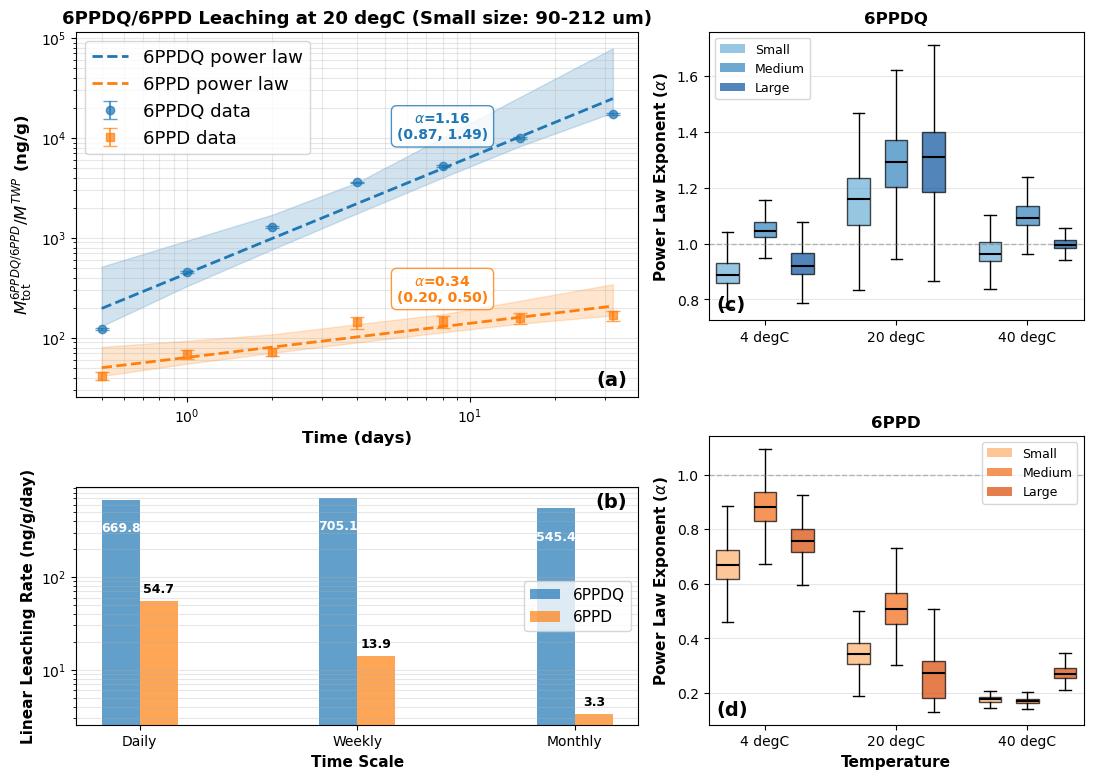

6PPDQ (20 degC, S) Power Law Fit:
  Exponent alpha = 1.162 (95% CI: 0.868, 1.485)
  Prefactor a = 441.01 (95% CI: 328.85, 938.58)
6PPD (20 degC, S) Power Law Fit:
  Exponent alpha = 0.341 (95% CI: 0.200, 0.501)
  Prefactor a = 63.76 (95% CI: 55.11, 93.57)
6PPDQ Linear Leaching Rates (ng/g/day):
  Daily (2 points): 669.82
  Weekly (5 points): 705.12
  Monthly (all retained points): 545.43
6PPD Linear Leaching Rates (ng/g/day):
  Daily (2 points): 54.68
  Weekly (5 points): 13.92
  Monthly (all retained points): 3.35


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print('n_figure_2_v3: alpha-boxplot four-panel figure with Vw=38.33 mL flushing masks')

# Uses outputs from the first cell: flushing_round_table_v3.
time = np.loadtxt('./data/EPT.csv', delimiter=',')
tire_mass = 0.5  # g
flushing_threshold = 1.0
pt_cols = [f'Pt{i + 1}' for i in range(len(time))]

temperatures = ['4C', '20C', '40C']
sizes = ['S', 'M', 'L']
temp_labels = {'4C': '4 degC', '20C': '20 degC', '40C': '40 degC'}
temp_tick_labels = {'4C': '4 degC', '20C': '20 degC', '40C': '40 degC'}
size_labels = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
size_lookup = {'S': '90-212 um', 'M': '212-500 um', 'L': '500-1000 um'}

# Colors for sizes, matching the v2 alpha-boxplot cell.
colors_ppdq = {'S': '#6baed6', 'M': '#3182bd', 'L': '#08519c'}
colors_ppd = {'S': '#fdae6b', 'M': '#f16913', 'L': '#d94801'}

def get_flushing_mask(temp, size):
    row = flushing_round_table_v3.loc[
        (flushing_round_table_v3['Temp'] == temp_labels[temp]) &
        (flushing_round_table_v3['Size'] == size_lookup[size]),
        pt_cols,
    ]
    if row.empty:
        raise ValueError(f'No flushing-round row found for {temp}_{size}; run the first cell first.')
    rounds = row.iloc[0].to_numpy(dtype=float)
    return rounds > flushing_threshold, rounds

def load_mean_std(compound, temp, size):
    data = np.loadtxt(f'./data/{compound}_{temp}_{size}.csv', delimiter=',')
    mean = np.nanmean(data, axis=1) / tire_mass
    std = np.nanstd(data, axis=1) / tire_mass
    return mean, std

def retained_series(compound, temp, size):
    mean, std = load_mean_std(compound, temp, size)
    good_mask, rounds = get_flushing_mask(temp, size)
    finite_mask = np.isfinite(mean) & (mean > 0)
    mask = good_mask & finite_mask
    if mask.sum() < 3:
        raise ValueError(f'Need at least 3 retained points for {compound}_{temp}_{size}.')
    return time[mask], mean[mask], std[mask], mask, rounds

def fit_power_law(time_data, mass_data):
    exponent, log_prefactor = np.polyfit(np.log(time_data), np.log(mass_data), 1)
    return np.exp(log_prefactor), exponent

def calculate_linear_rate(time_data, mass_data):
    slope, _ = np.polyfit(time_data, mass_data, 1)
    return slope

def bootstrap_power_law(time_data, mass_data, x_eval, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    fits = []
    exponents = []
    prefactors = []
    n_points = len(time_data)
    for _ in range(n_bootstrap):
        idx = rng.choice(n_points, size=n_points, replace=True)
        boot_time = time_data[idx]
        boot_mass = mass_data[idx]
        if len(np.unique(boot_time)) < 2:
            continue
        a_boot, b_boot = fit_power_law(boot_time, boot_mass)
        prefactors.append(a_boot)
        exponents.append(b_boot)
        fits.append(a_boot * x_eval**b_boot)
    return np.asarray(fits), np.asarray(exponents), np.asarray(prefactors)

def bootstrap_alpha(time_data, mass_data, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    alphas = []
    n_points = len(time_data)
    for _ in range(n_bootstrap):
        idx = rng.choice(n_points, size=n_points, replace=True)
        boot_time = time_data[idx]
        boot_mass = mass_data[idx]
        if len(np.unique(boot_time)) < 2:
            continue
        _, alpha_boot = fit_power_law(boot_time, boot_mass)
        alphas.append(alpha_boot)
    return alphas

# Panels (a) and (b): 20 degC, 90-212 um example, following the v2 cell.
example_temp = '20C'
example_size = 'S'
time_fit, ppdq_mean_fit, ppdq_std_fit, _, ppdq_rounds = retained_series('PPDQ', example_temp, example_size)
_, ppd_mean_fit, ppd_std_fit, _, _ = retained_series('PPD', example_temp, example_size)
first_good_pt = np.flatnonzero(ppdq_rounds > flushing_threshold)[0] + 1
print(f'Example case {example_temp}_{example_size}: N > {flushing_threshold:.1f}, first retained point Pt{first_good_pt}, retained points={len(time_fit)}')

a_ppdq, b_ppdq = fit_power_law(time_fit, ppdq_mean_fit)
a_ppd, b_ppd = fit_power_law(time_fit, ppd_mean_fit)

bootstrap_fits_ppdq, bootstrap_exponents_ppdq, bootstrap_prefactors_ppdq = bootstrap_power_law(time_fit, ppdq_mean_fit, time_fit, seed=42)
bootstrap_fits_ppd, bootstrap_exponents_ppd, bootstrap_prefactors_ppd = bootstrap_power_law(time_fit, ppd_mean_fit, time_fit, seed=43)

lower_bound_ppdq = np.percentile(bootstrap_fits_ppdq, 2.5, axis=0)
upper_bound_ppdq = np.percentile(bootstrap_fits_ppdq, 97.5, axis=0)
b_ppdq_lower = np.percentile(bootstrap_exponents_ppdq, 2.5)
b_ppdq_upper = np.percentile(bootstrap_exponents_ppdq, 97.5)
a_ppdq_lower = np.percentile(bootstrap_prefactors_ppdq, 2.5)
a_ppdq_upper = np.percentile(bootstrap_prefactors_ppdq, 97.5)

lower_bound_ppd = np.percentile(bootstrap_fits_ppd, 2.5, axis=0)
upper_bound_ppd = np.percentile(bootstrap_fits_ppd, 97.5, axis=0)
b_ppd_lower = np.percentile(bootstrap_exponents_ppd, 2.5)
b_ppd_upper = np.percentile(bootstrap_exponents_ppd, 97.5)
a_ppd_lower = np.percentile(bootstrap_prefactors_ppd, 2.5)
a_ppd_upper = np.percentile(bootstrap_prefactors_ppd, 97.5)

# Calculate linear leaching rates at different time scales.
n_week = min(5, len(time_fit))
rate_ppdq_daily = calculate_linear_rate(time_fit[:2], ppdq_mean_fit[:2])
rate_ppd_daily = calculate_linear_rate(time_fit[:2], ppd_mean_fit[:2])
rate_ppdq_weekly = calculate_linear_rate(time_fit[:n_week], ppdq_mean_fit[:n_week])
rate_ppd_weekly = calculate_linear_rate(time_fit[:n_week], ppd_mean_fit[:n_week])
rate_ppdq_monthly = calculate_linear_rate(time_fit, ppdq_mean_fit)
rate_ppd_monthly = calculate_linear_rate(time_fit, ppd_mean_fit)

# Panels (c) and (d): alpha distributions for all temp/size cases with case-specific flushing masks.
alpha_ppdq = {temp: {size: [] for size in sizes} for temp in temperatures}
alpha_ppd = {temp: {size: [] for size in sizes} for temp in temperatures}

for temp in temperatures:
    for size in sizes:
        t_ppdq, ppdq_valid, _, _, rounds_case = retained_series('PPDQ', temp, size)
        t_ppd, ppd_valid, _, _, _ = retained_series('PPD', temp, size)
        first_pt = np.flatnonzero(rounds_case > flushing_threshold)[0] + 1
        print(f'{temp}_{size}: alpha mask starts at Pt{first_pt}, retained points={len(t_ppdq)}')
        seed_offset = 100 * temperatures.index(temp) + 10 * sizes.index(size)
        alpha_ppdq[temp][size] = bootstrap_alpha(t_ppdq, ppdq_valid, seed=1000 + seed_offset)
        alpha_ppd[temp][size] = bootstrap_alpha(t_ppd, ppd_valid, seed=2000 + seed_offset)

# Create figure with custom layout - left panels with custom heights, right panels square.
fig = plt.figure(figsize=(13, 9))
gs_main = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.15)

gs_left = gs_main[0, 0].subgridspec(2, 1, height_ratios=[2, 1.3], hspace=0.3)
ax1 = fig.add_subplot(gs_left[0, 0])
ax2 = fig.add_subplot(gs_left[1, 0])

gs_right = gs_main[0, 1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.4)
ax3 = fig.add_subplot(gs_right[0, 0])
ax4 = fig.add_subplot(gs_right[1, 0])

# Panel (a): power-law example.
color1 = 'tab:blue'
color2 = 'tab:orange'
ax1.errorbar(time_fit, ppdq_mean_fit, yerr=ppdq_std_fit, marker='o', linestyle='none',
             label='6PPDQ data', capsize=5, alpha=0.7, color=color1)
ax1.errorbar(time_fit, ppd_mean_fit, yerr=ppd_std_fit, marker='s', linestyle='none',
             label='6PPD data', capsize=5, alpha=0.7, color=color2)

ax1.plot(time_fit, a_ppdq * time_fit**b_ppdq, '--', color=color1, linewidth=2,
         label='6PPDQ power law')
ax1.fill_between(time_fit, lower_bound_ppdq, upper_bound_ppdq, color=color1, alpha=0.2)
ax1.plot(time_fit, a_ppd * time_fit**b_ppd, '--', color=color2, linewidth=2,
         label='6PPD power law')
ax1.fill_between(time_fit, lower_bound_ppd, upper_bound_ppd, color=color2, alpha=0.2)

mid_idx = min(len(time_fit) // 2 + 1, len(time_fit) - 1)
line_break = chr(10)
ppdq_alpha_label = '$\\alpha$={:.2f}'.format(b_ppdq) + line_break + '({:.2f}, {:.2f})'.format(b_ppdq_lower, b_ppdq_upper)
ppd_alpha_label = '$\\alpha$={:.2f}'.format(b_ppd) + line_break + '({:.2f}, {:.2f})'.format(b_ppd_lower, b_ppd_upper)
ax1.text(time_fit[mid_idx], a_ppdq * time_fit[mid_idx]**b_ppdq * 2.0,
         ppdq_alpha_label, color=color1, fontsize=10, fontweight='bold', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color1, alpha=0.8))
ax1.text(time_fit[mid_idx], a_ppd * time_fit[mid_idx]**b_ppd * 1.8,
         ppd_alpha_label, color=color2, fontsize=10, fontweight='bold', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color2, alpha=0.8))

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Time (days)', fontsize=12, fontweight='bold')
ax1.set_ylabel(r'$M_{\mathrm{tot}}^{6PPDQ/6PPD}/M^{TWP}$ (ng/g)', fontsize=12, fontweight='bold', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which='both', alpha=0.3)
ax1.set_title('6PPDQ/6PPD Leaching at 20 degC (Small size: 90-212 um)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=13)
ax1.text(0.98, 0.02, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold',
         verticalalignment='bottom', horizontalalignment='right')

# Panel (b): linear leaching rates for the example case.
x_pos = np.arange(3)
width = 0.175
bars1 = ax2.bar(x_pos - width / 2, [rate_ppdq_daily, rate_ppdq_weekly, rate_ppdq_monthly],
                width, label='6PPDQ', color='tab:blue', alpha=0.7)
bars2 = ax2.bar(x_pos + width / 2, [rate_ppd_daily, rate_ppd_weekly, rate_ppd_monthly],
                width, label='6PPD', color='tab:orange', alpha=0.7)
ax2.set_ylabel('Linear Leaching Rate (ng/g/day)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Time Scale', fontsize=11, fontweight='bold')
ax2.set_yscale('log')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Daily', 'Weekly', 'Monthly'])
ax2.legend(fontsize=11)
ax2.grid(True, axis='y', alpha=0.3, which='both')

for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, height / 2,
             f'{height:.1f}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, height * 1.15,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.text(0.98, 0.98, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold',
         verticalalignment='top', horizontalalignment='right')

# Panel (c): 6PPDQ alpha boxplot.
positions_ppdq = []
data_ppdq = []
colors_list_ppdq = []
labels_temp = []
pos = 0
for i, temp in enumerate(temperatures):
    for size in sizes:
        positions_ppdq.append(pos)
        data_ppdq.append(alpha_ppdq[temp][size])
        colors_list_ppdq.append(colors_ppdq[size])
        pos += 1
    pos += 0.5
    labels_temp.append(temp_tick_labels[temp])

bp3 = ax3.boxplot(data_ppdq, positions=positions_ppdq, widths=0.6, patch_artist=True,
                  showfliers=False, medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp3['boxes'], colors_list_ppdq):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel(r'Power Law Exponent ($\alpha$)', fontsize=11, fontweight='bold')
ax3.set_title('6PPDQ', fontsize=12, fontweight='bold')
ax3.set_xticks([1, 4.5, 8])
ax3.set_xticklabels(labels_temp)
ax3.grid(True, axis='y', alpha=0.3)
ax3.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
legend_elements_ppdq = [Patch(facecolor=colors_ppdq[s], alpha=0.7, label=size_labels[s]) for s in sizes]
ax3.legend(handles=legend_elements_ppdq, loc='upper left', fontsize=9)
ax3.text(0.02, 0.02, '(c)', transform=ax3.transAxes, fontsize=14, fontweight='bold',
         verticalalignment='bottom', horizontalalignment='left')

# Panel (d): 6PPD alpha boxplot.
positions_ppd = []
data_ppd = []
colors_list_ppd = []
pos = 0
for temp in temperatures:
    for size in sizes:
        positions_ppd.append(pos)
        data_ppd.append(alpha_ppd[temp][size])
        colors_list_ppd.append(colors_ppd[size])
        pos += 1
    pos += 0.5

bp4 = ax4.boxplot(data_ppd, positions=positions_ppd, widths=0.6, patch_artist=True,
                  showfliers=False, medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp4['boxes'], colors_list_ppd):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_ylabel(r'Power Law Exponent ($\alpha$)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Temperature', fontsize=11, fontweight='bold')
ax4.set_title('6PPD', fontsize=12, fontweight='bold')
ax4.set_xticks([1, 4.5, 8])
ax4.set_xticklabels(labels_temp)
ax4.grid(True, axis='y', alpha=0.3)
ax4.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
legend_elements_ppd = [Patch(facecolor=colors_ppd[s], alpha=0.7, label=size_labels[s]) for s in sizes]
ax4.legend(handles=legend_elements_ppd, loc='upper right', fontsize=9)
ax4.text(0.02, 0.02, '(d)', transform=ax4.transAxes, fontsize=14, fontweight='bold',
         verticalalignment='bottom', horizontalalignment='left')

plt.tight_layout()
plt.show()

print('6PPDQ (20 degC, S) Power Law Fit:')
print(f'  Exponent alpha = {b_ppdq:.3f} (95% CI: {b_ppdq_lower:.3f}, {b_ppdq_upper:.3f})')
print(f'  Prefactor a = {a_ppdq:.2f} (95% CI: {a_ppdq_lower:.2f}, {a_ppdq_upper:.2f})')
print('6PPD (20 degC, S) Power Law Fit:')
print(f'  Exponent alpha = {b_ppd:.3f} (95% CI: {b_ppd_lower:.3f}, {b_ppd_upper:.3f})')
print(f'  Prefactor a = {a_ppd:.2f} (95% CI: {a_ppd_lower:.2f}, {a_ppd_upper:.2f})')
print('6PPDQ Linear Leaching Rates (ng/g/day):')
print(f'  Daily (2 points): {rate_ppdq_daily:.2f}')
print(f'  Weekly ({n_week} points): {rate_ppdq_weekly:.2f}')
print(f'  Monthly (all retained points): {rate_ppdq_monthly:.2f}')
print('6PPD Linear Leaching Rates (ng/g/day):')
print(f'  Daily (2 points): {rate_ppd_daily:.2f}')
print(f'  Weekly ({n_week} points): {rate_ppd_weekly:.2f}')
print(f'  Monthly (all retained points): {rate_ppd_monthly:.2f}')

fig.savefig('Figure_2.png', dpi=300, bbox_inches='tight')